In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import itertools as it
from matplotlib import rcParams
import matplotlib.colors as mcolors
from utils.analysis import uq_get_obs, uq_get_sim

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231117'
#prefix_uptake = '20240401'
prefix_list = [prefix_default] #, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231117', 'UQ_20240101', 'UQ_20240104'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE']

collection_obs = uq_get_obs(VAR_LIST)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list_uq):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Phenology', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collection_sim[prefix] = collect

collection_sim_target = {}
for prefix in prefix_list:
    collection_sim_target[prefix] = uq_get_sim(prefix, VAR_LIST)

FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/wolf2/cades/cli185/scratch/ywo/ELM_Phenology/output/extract/20231117/extract_ts_productivity.csv'

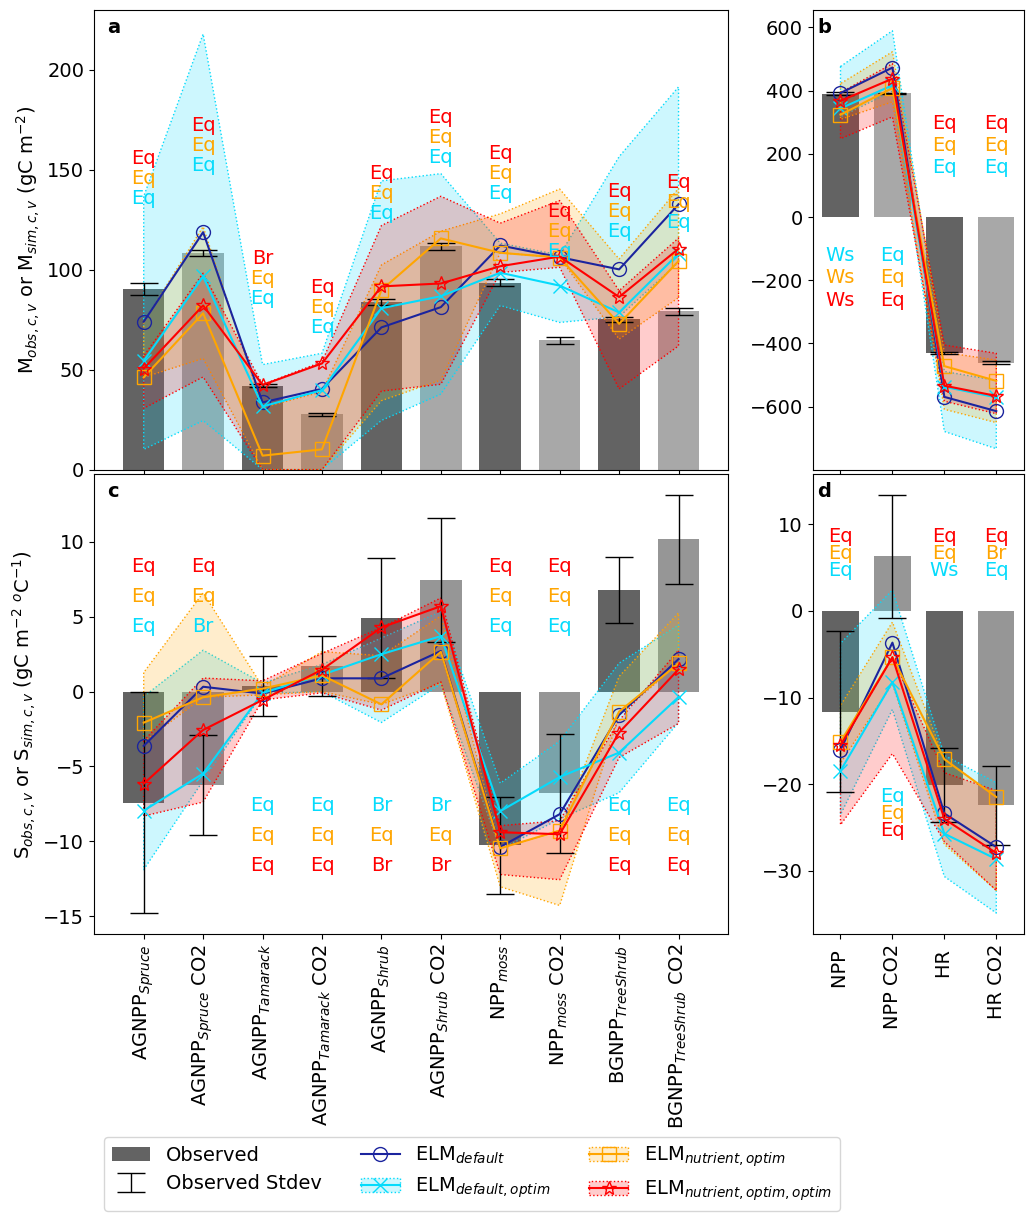

In [ ]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
sub1 = np.arange(10)
sub2 = np.arange(10,14)
xticklabels = {
    0: [var.replace('_','$_{')+'}$'+f' {co2}' for var in VAR_SUBSET[:5] \
        for co2 in ['', 'CO2']],
    1: [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET[5:] \
        for co2 in ['', 'CO2']],
}
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# (note: the index values is ensemble_id minus one, because Python index starts
#  from 0, and ensemble id starts from 1)
n_best_ind = 20
best_ind = {'UQ_20231117': 569, 'UQ_20240101': 3000, 'UQ_20240102': 3994}

obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 1].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 3].reshape(1,-1)
sims_target_mean = {}
sims_target_slope = {}
for prefix in collection_sim_target:
    sims_target_mean[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 0].reshape(1, -1)
    sims_target_slope[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 2].reshape(1, -1)

#
fig, axes = plt.subplots(2, 2, figsize = (12, 12), # sharex = True, 
                         gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(hspace = 0.01)
for s, sub in enumerate([sub1, sub2]):
    ax = axes.flat[s]
    h1 = ax.bar(np.arange(len(sub)), obs_mean[0, sub], width = 0.7,
                color = ['#636363', '#a8a8a8'] * len(sub))
    he = ax.errorbar(np.arange(len(sub)), obs_mean[0, sub], 
                     yerr = obs_mean_std[0, sub], lw = 0, 
                     ecolor = 'k', elinewidth = 1, capsize = 10, barsabove = True)
    if s == 0:
        ax.set_ylabel('M$_{obs,c,v}$ or M$_{sim,c,v}$ (gC m$^{-2}$)')
    ax = axes.flat[2+s]
    h1 = ax.bar(np.arange(len(sub)), obs_slope[0, sub], width = 0.7,
                color = ['#636363', '#969696'] * len(sub))
    ax.errorbar(np.arange(len(sub)), obs_slope[0, sub], yerr = obs_slope_std[0, sub], lw = 0, 
                ecolor = 'k', elinewidth = 1, capsize = 10, barsabove = True)
    if s == 0:
        ax.set_ylabel('S$_{obs,c,v}$ or S$_{sim,c,v}$ (gC m$^{-2}$ $^o$C$^{-1}$)')

labs = 'abcd'
clist = ['#1b249e', '#05dbfc', '#ffa500', '#ff0000'] # '#1a80bb'
mlist = ['o', 'x', 's', '*']
msize = 10
h2 = [None] * len(prefix_list_uq)
h3 = [None] * len(prefix_list_uq)
h4 = [None] * 2


# save whether within the std of observation
within_obs_std = {}

for p, prefix in enumerate(prefix_list):
    for s, sub in enumerate([sub1, sub2]):
        ax = axes.flat[s]
        h4[p], = ax.plot(np.arange(len(sub)), # - 0.25 + p/5,
                         sims_target_mean[prefix][0, sub], markerfacecolor = 'none',
                         ls = '-', color = clist[p], markersize = msize, marker = mlist[p])
        ax.set_xticks(np.arange(len(sub)))
        ax.set_xticklabels([])
        #ax.set_xticklabels(xticklabels[s], rotation = 90)

        within_obs_std[(prefix, s, 'mean')] = \
            (sims_target_mean[prefix][0, sub] >= (obs_mean[0, sub] - obs_mean_std[0, sub])) & \
            (sims_target_mean[prefix][0, sub] <= (obs_mean[0, sub] + obs_mean_std[0, sub]))

        ax = axes.flat[2+s]
        h4[p], = ax.plot(np.arange(len(sub)), # - 0.25 + p/5,
                         sims_target_slope[prefix][0, sub], markerfacecolor = 'none',
                         ls = '-', color = clist[p], markersize = msize, marker = mlist[p])
        ax.set_xticks(np.arange(len(sub)))
        ax.set_xticklabels(xticklabels[s], rotation = 90)
        #ax.grid(True)

        within_obs_std[(prefix, s, 'slope')] = \
            (sims_target_slope[prefix][0, sub] >= (obs_slope[0, sub] - obs_slope_std[0, sub])) & \
            (sims_target_slope[prefix][0, sub] <= (obs_slope[0, sub] + obs_slope_std[0, sub]))


for p, prefix in enumerate(prefix_list_uq, len(prefix_list)):
    for s, sub in enumerate([sub1, sub2]):

        # the 2 is ACO2 and ECO2
        sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
        sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

        # find the best runs
        rmse_weights = np.repeat(np.array([1, 1, 1, 1, 1, 1, 1]), 2).reshape(1,-1)
        rmse_mean = np.mean((np.abs(sim_mean - obs_mean) / np.abs(obs_mean))*rmse_weights, axis = 1)
        rmse_slope = np.mean((np.abs(sim_slope - obs_slope) / np.abs(obs_slope))*rmse_weights, axis = 1)
        rmse_tot = rmse_mean + rmse_slope
        best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

        sim_mean_bi = sim_mean[best_inds, :]
        sim_slope_bi = sim_slope[best_inds, :]

        ax = axes.flat[s]
        sim_mean_temp = sim_mean[best_ind[prefix], sub]
        # sim_mean_temp = sim_mean_bi.mean(axis = 0)[sub]
        h2[p-len(prefix_list)], = ax.plot(np.arange(len(sub)), # - 0.25 + p/5, 
                            sim_mean_temp, ls = '-', color = clist[p], 
                            markersize = msize, marker = mlist[p], markerfacecolor = 'none')
        face_color = mcolors.to_rgba(clist[p], alpha=0.2)
        h3[p-len(prefix_list)] = ax.fill_between(np.arange(len(sub)), # - 0.25 + p/5,
                                np.min(sim_mean_bi, axis = 0)[sub],
                                np.max(sim_mean_bi, axis = 0)[sub], 
                                facecolor=face_color, edgecolor=clist[p], ls = ':')

        within_obs_std_temp = \
            (sim_mean_temp >= (obs_mean[0, sub] - obs_mean_std[0, sub])) & \
            (sim_mean_temp <= (obs_mean[0, sub] + obs_mean_std[0, sub]))
        for x in range(len(sub)):
            spacing = {0: 10, 1: 70}
            y0 = (obs_mean[0, sub] + obs_mean_std[0, sub])[x]
            if s == 0:
                y = y0 + 30 + spacing[s] * p
            else:
                if y0 > 0:
                    y = - 70 - spacing[s] * p
                else:
                    y = 70 + spacing[s] * p

            if (within_obs_std_temp[x] & ~within_obs_std[(prefix_default, s, 'mean')][x]):
                ax.text(x, y, 'Br', color = clist[p], horizontalalignment = 'center')
            elif (~within_obs_std_temp[x] & within_obs_std[(prefix_default, s, 'mean')][x]):
                ax.text(x, y, 'Ws', color = clist[p], horizontalalignment = 'center')
            else:
                ax.text(x, y, 'Eq', color = clist[p], horizontalalignment = 'center')
        if s == 0:
            ax.set_ylim([0, 230])

        ax = axes.flat[2+s]
        sim_slope_temp = sim_slope[best_ind[prefix], sub]
        # sim_slope_temp = sim_slope_bi.mean(axis = 0)[sub]
        h2[p-len(prefix_list)], = ax.plot(np.arange(len(sub)), # - 0.25 + p/5,
                            sim_slope_temp, ls = '-', color = clist[p],
                            markersize = msize, marker = mlist[p], markerfacecolor = 'none')
        face_color = mcolors.to_rgba(clist[p], alpha=0.2)
        h3[p-len(prefix_list)] = ax.fill_between(np.arange(len(sub)), # - 0.25 + p/5,
                                 np.min(sim_slope_bi, axis = 0)[sub],
                                 np.max(sim_slope_bi, axis = 0)[sub], 
                                 facecolor=face_color, edgecolor=clist[p], ls = ':')
        ax.set_xticks(np.arange(len(sub)))
        #ax.set_ylim([-38, 12])

        within_obs_std_temp = \
            (sim_slope_temp >= (obs_slope[0, sub] - obs_slope_std[0, sub])) & \
            (sim_slope_temp <= (obs_slope[0, sub] + obs_slope_std[0, sub]))
        for x in range(len(sub)):
            spacing = {0: 2, 1: 2}
            y0 = (obs_slope[0, sub] + obs_slope_std[0, sub])[x]
            if y0 < 0:
                y = 2 + spacing[s] * p
            else:
                if s == 1 and x == 1:
                    y = - 20 - spacing[s] * p
                else:
                    y = - 6 - spacing[s] * p
            if (within_obs_std_temp[x] & ~within_obs_std[(prefix_default, s, 'slope')][x]):
                ax.text(x, y, 'Br', color = clist[p], horizontalalignment = 'center')
            elif (~within_obs_std_temp[x] & within_obs_std[(prefix_default, s, 'slope')][x]):
                ax.text(x, y, 'Ws', color = clist[p], horizontalalignment = 'center')
            else:
                ax.text(x, y, 'Eq', color = clist[p], horizontalalignment = 'center')

# legend_names = ['Obs', 'std Obs'] + prefix_list + prefix_list_uq + [f'rng {x}' for x in prefix_list_uq]
legend_names = ['Observed', 'Observed Stdev', 'ELM$_{default}$', 'ELM$_{default,optim}$', 
                'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']

ax = axes.flat[0]
ax.legend([h1[0], he] + [h4[0]] + list(zip(h2, h3)), legend_names,
          bbox_to_anchor = (0, -1.43), ncol = 3, loc = 'upper left')
for i in range(4):
    axes.flat[i].text(0.02, 0.95, labs[i], fontdict = {'weight': 'bold'}, 
                      transform = axes.flat[i].transAxes)